In [1]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
from itertools import product


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
import simulations.genomes1000_sim as sim_functions

intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'

In [4]:
# PARAMETERS
generate_sim = True
evaluate_sim = True
# generate all combinations of e and ps variables
ps_list = [True,False]
e_list = [0.5,1]
num_markers_assoc_list = [100,2000]
init_list = range(100) # 100 random initializations for each combination
bfile_path=f'{output_dir}/G'
af_df_filepath=admixture_filepath
# PARAMETERS

## Explore 1000 genomes data

### Run GWAS with and without PCs and see how much genetic coefficients change 

Code to run SAIGE and PLINK gwas

In [ ]:
def generate_phenotype_file(simulation_metadata_path, phenotypic_subgroup, covar_filepath, phenotype_file_plink, phenotype_file_saige):
    # write plink phenotype file
    with open(simulation_metadata_path, "rb") as f:
        simulation_metadata = pickle.load(f)
    phenotypic_subgroups = simulation_metadata['phenotypic_subgroups']

    # write plink phenotype file
    pheno = phenotypic_subgroups[phenotypic_subgroups['phenotypic_subgroup']==phenotypic_subgroup][['IID','subgroup']].rename(columns={'subgroup':'Phenotype'})
    pheno['FID'] = pheno['IID']
    pheno['Phenotype'] = pheno['Phenotype'].astype(int)
    pheno[['FID','IID','Phenotype']].set_index('FID').to_csv(phenotype_file_plink)

    # write saige phenotype file (this includes covariates)
    pheno.drop('FID',axis=1,inplace=True)
    covar_df = pd.read_csv(covar_filepath).drop('FID',axis=1)
    saige_phenoFile = pheno.merge(covar_df,how='inner',on='IID').set_index('IID')
    assert (set(saige_phenoFile.index) == set(pheno['IID'])) and (set(pheno['IID'])==set(covar_df['IID']))
    saige_phenoFile.to_csv(phenotype_file_saige,sep='\t')


def run_plink_gwas(bfile, covariate_file, phenotype_file, out):
    if covariate_file is None:
        covar_section = ''
        covar_flag = 'allow-no-covars'
    else:
        covar_section = f'--covar {covariate_file} --covar-variance-standardize'
        covar_flag = ''
    result = subprocess.run(f'module unload plink && module load plink/2.0a5.13 && plink --bfile {bfile}\
                        {covar_section}\
                        --pheno {phenotype_file}\
                        --glm omit-ref {covar_flag}\
                        --out {out}\
                        --1 --no-pheno', shell=True, capture_output=True, text=True, executable='/bin/bash')
    result.check_returncode()

In [18]:
output_file_suffix = sim_functions.get_output_file_suffix(ps=True,e=0.5,init=0,num_markers_assoc=100)
phenotypic_subgroup = 0
generate_phenotype_file(simulation_metadata_path=f'{output_dir}/simulation_metadata_{output_file_suffix}.pkl', phenotypic_subgroup=phenotypic_subgroup, 
                    covar_filepath=f'{output_dir}/COVARIATE_FILE',
                    phenotype_file_plink=f'{intermediate_plink_dir}/PHENOTYPE_FILE_Subgroup{phenotypic_subgroup}_{output_file_suffix}',
                    phenotype_file_saige=f'{intermediate_saige_dir}/PHENOTYPE_FILE_Subgroup{phenotypic_subgroup}_{output_file_suffix}')

In [29]:
def split_plink_bfile(bfile):
    for chr in range(1,23):
        result = subprocess.run(f'''module load plink/1.9 && plink --bfile {bfile} \
          --chr {chr} \
          --make-bed \
          --out {bfile}_{chr}''', shell=True, capture_output=True, text=True, executable='/bin/bash')
        result.check_returncode()

In [30]:
split_plink_bfile(f'{output_dir}/G')

In [ ]:
# step 0: create sparse GRM (run once)
def run_step0(plinkFile,out):
    result = subprocess.run(f"module load R/4.3.3 \
                            && Rscript $(echo $CMAKE_PREFIX_PATH | tr ':' '\n' | grep R/4.3.3)/SAIGE/extdata/createSparseGRM.R\
                            --plinkFile={plinkFile} \
                            --numRandomMarkerforSparseKin=10000\
                            --relatednessCutoff=0.125\
                            --nThreads=16\
                            --outputPrefix={out}", shell=True, capture_output=True, text=True, executable='/bin/bash') 
    result.check_returncode()
    sparseGRMFile = f'{out}_relatednessCutoff_0.125_10000_randomMarkersUsed.sparseGRM.mtx'
    sparseGRMSampleIDFile = f'{out}_relatednessCutoff_0.125_10000_randomMarkersUsed.sparseGRM.mtx.sampleIDs.txt'
    return sparseGRMFile,sparseGRMSampleIDFile

# step 1: run null GRM for each phenotype
def run_step1(sparseGRMFile, sparseGRMSampleIDFile, plinkFile, phenoFile, out):
    saige_phenoFile = pd.read_csv(phenoFile,sep='\t')
    print([i for i in saige_phenoFile.columns if i not in ['Phenotype','IID']])
    # run null model
    result = subprocess.run(f"module load R/4.3.3 \
                            && Rscript $(echo $CMAKE_PREFIX_PATH | tr ':' '\n' | grep R/4.3.3)/SAIGE/extdata/step1_fitNULLGLMM.R \
                            --sparseGRMFile={sparseGRMFile} \
                            --sparseGRMSampleIDFile={sparseGRMSampleIDFile} \
                            --useSparseGRMtoFitNULL=TRUE \
                            --plinkFile={plinkFile} \
                            --phenoFile={phenoFile}\
                            --skipVarianceRatioEstimation=FALSE \
                            --phenoCol=Phenotype \
                            --covarColList={','.join([i for i in saige_phenoFile.columns if i not in ['Phenotype','IID']])} \
                            --qCovarColList=Sex \
                            --sampleIDColinphenoFile=IID \
                            --traitType=binary \
                            --outputPrefix={out} \
                            --nThreads=16 \
                            --isCovariateOffset=FALSE \
                            --IsOverwriteVarianceRatioFile=TRUE", shell=True, capture_output=True, text=True, executable='/bin/bash')
    result.check_returncode()
    GMMATmodelFile = f'{out}.rda'
    varianceRatioFile = f'{out}.varianceRatio.txt'
    return GMMATmodelFile, varianceRatioFile

def submit_step2_job(bfile, GMMATmodelFile, varianceRatioFile, sparseGRMFile, sparseGRMSampleIDFile, intermediate_saige_dir, out):
    # run association tests LOCO
    for chr in range(1,23):
        job_name = f"{out}_{chr}"
        slurm_script = f'{intermediate_saige_dir}/{job_name}.sh'
        slurm_content = f"""#!/bin/bash
    #SBATCH --job-name={job_name}
    #SBATCH --output={intermediate_saige_dir}/{out}.out
    #SBATCH --error={intermediate_saige_dir}/{out}.err
    #SBATCH --time=24:00:00
    #SBATCH --cpus-per-task=1
    #SBATCH --mem=4G

    module load R/4.3.3 
    Rscript $(echo $CMAKE_PREFIX_PATH | tr ':' '\n' | grep R/4.3.3)/SAIGE/extdata/step2_SPAtests.R \\
    --bedFile={bfile}_{chr}.bed \\
    --bimFile={bfile}_{chr}.bim \\
    --famFile={bfile}_{chr}.fam \\
    --AlleleOrder=alt-first \\
    --SAIGEOutputFile={out} \\
    --GMMATmodelFile={GMMATmodelFile} \\
    --varianceRatioFile={varianceRatioFile} \\
    --LOCO=TRUE \\
    --chrom={chr} \\
    --is_Firth_beta=TRUE    \\
    --pCutoffforFirth=0.01 \\
    --sparseGRMFile={sparseGRMFile} \\
    --sparseGRMSampleIDFile={sparseGRMSampleIDFile}
    """

        # Write script to file
        with open(slurm_script, 'w') as f:
            f.write(slurm_content)

        # Submit the job
        subprocess.run(f"sbatch {slurm_script}", shell=True, check=True)

def run_saige(plinkFile,phenoFile,output_dir):
    print('step 0',flush=True)
    sparseGRMFile,sparseGRMSampleIDFile = run_step0(plinkFile=plinkFile,out=f'{output_dir}/SAIGE_sparseGRM')
    print('step 1',flush=True)
    run_step1(sparseGRMFile=sparseGRMFile,sparseGRMSampleIDFile=sparseGRMSampleIDFile,
              plinkFile=plinkFile, phenoFile=phenoFile,
              out=f'{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_SAIGE')

    # run association tests LOCO
    submit_step2_job(bfile=f'{output_dir}/G', out)


run_saige(plinkFile=f'{output_dir}/G',phenoFile=f'{intermediate_saige_dir}/PHENOTYPE_FILE_Subgroup{phenotypic_subgroup}_{output_file_suffix}',output_dir=output_dir)

step 0
step 1
['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'Sex']
Warning messages:
1: replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘SAIGE’ 
2: replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘SAIGE’ 
3: replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘SAIGE’ 
Loading required package: optparse

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /nfs/sw/miniconda3/miniconda3-3.22.0/envs/R-4.3.3/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC

In [ ]:




def submit_step2_job(pheno_dir, chunk_file, chunk_idx):
    job_name = f"{pheno_dir}_chunk_{chunk_idx:03d}"
    slurm_script = f'{gwas_score_dir}/revision/{job_name}.sh'
    slurm_content = f"""#!/bin/bash
#SBATCH --job-name={job_name}
#SBATCH --output={gwas_data_dir}/{pheno_dir}_SAIGE/SAIGE_{chunk_idx}.out
#SBATCH --error={gwas_data_dir}/{pheno_dir}_SAIGE/SAIGE_{chunk_idx}.err
#SBATCH --time=24:00:00
#SBATCH --cpus-per-task=1
#SBATCH --mem=4G

module load R/4.3.3 
Rscript $(echo $CMAKE_PREFIX_PATH | tr ':' '\n' | grep R/4.3.3)/SAIGE/extdata/step2_SPAtests.R \\
--bedFile={bfile}.bed \\
--bimFile={bfile}.bim \\
--famFile={bfile}.fam \\
--AlleleOrder=alt-first \\
--idstoIncludeFile={chunk_file} \\
--SAIGEOutputFile={gwas_data_dir}/{pheno_dir}_SAIGE/SAIGE_RESULTS_{chunk_idx} \\
--GMMATmodelFile={gwas_data_dir}/{pheno_dir}_SAIGE/SAIGE_RESULTS.rda \\
--varianceRatioFile={gwas_data_dir}/{pheno_dir}_SAIGE/SAIGE_RESULTS.varianceRatio.txt \\
--LOCO=FALSE \\
--is_Firth_beta=TRUE    \\
--pCutoffforFirth=0.01 \\
--sparseGRMFile={gwas_data_dir}/SNPS/SAIGE_sparseGRM_relatednessCutoff_0.125_2000_randomMarkersUsed.sparseGRM.mtx \\
--sparseGRMSampleIDFile={gwas_data_dir}/SNPS/SAIGE_sparseGRM_relatednessCutoff_0.125_2000_randomMarkersUsed.sparseGRM.mtx.sampleIDs.txt
"""

    # Write script to file
    with open(slurm_script, 'w') as f:
        f.write(slurm_content)

    # Submit the job
    subprocess.run(f"sbatch {slurm_script}", shell=True, check=True)
    os.remove(slurm_script)

In [ ]:
def run_phenotypicsubgroup_gwas(output_dir,output_file_suffix,intermediate_plink_dir,intermediate_saige_dir, phenotypic_subgroup):
    '''
    Runs PLINK and SAIGE GWAS and outputs to parquet file
    '''

    # write phenotype file
    phenotype_file_plink=f'{intermediate_plink_dir}/PHENOTYPE_FILE_Subgroup{phenotypic_subgroup}_{output_file_suffix}'
    phenotype_file_saige=f'{intermediate_saige_dir}/PHENOTYPE_FILE_Subgroup{phenotypic_subgroup}_{output_file_suffix}'
    generate_phenotype_file(simulation_metadata_path=f'{output_dir}/simulation_metadata_{output_file_suffix}.pkl', phenotypic_subgroup=phenotypic_subgroup, 
                    covar_filepath=f'{output_dir}/COVARIATE_FILE',
                    phenotype_file_plink=phenotype_file_plink,
                    phenotype_file_saige=phenotype_file_saige)

    # run PLINK GWAS (no covariates)
    run_plink_gwas(bfile=f'{output_dir}/G', covariate_file=None, phenotype_file=phenotype_file_plink, 
                   out=f'{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_False')

    # run PLINK GWAS (with age and pcs)
    run_plink_gwas(bfile=f'{output_dir}/G', covariate_file=f'{output_dir}/COVARIATE_FILE', phenotype_file=phenotype_file_plink, 
                   out=f'{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_True')
    
    # run SAIGE GWAS (with age and pcs)
    run_saige(plinkFile=f'{output_dir}/G',phenoFile=phenotype_file_saige,output_dir)
    

    # write plink results to parquet for quicker analysis - write all results to plink
    with open(f'{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_{cov_included}.log','r') as f:
        file = f.read()
        assert "End time" in file, f"plink ended with errors for {output_file_suffix}"
    plink_results = pd.read_csv(f'{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_{cov_included}.Phenotype.glm.logistic.hybrid',sep='\t')
    plink_results = plink_results[plink_results['TEST']=='ADD'].copy() # only write SNP effect size data
    plink_results["OR"] = pd.to_numeric(plink_results["OR"])
    plink_results.to_parquet(f'{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_{cov_included}_results.parquet', engine='pyarrow') # export to parquet format for quicker lookup later on
    # clean up for storage space
    os.remove(f'{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_{cov_included}.log')
    os.remove(f'{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_{cov_included}.Phenotype.glm.logistic.hybrid')


make graph of GWAS

In [ ]:
# ps = True
# e = 0.5
# init = 0
# num_markers_assoc = 2000
# phenotypic_subgroup = 2
# output_file_suffix = sim_functions.get_output_file_suffix(ps, e, init, num_markers_assoc)
# df_with = (pd.read_parquet(
#     f"{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_True_results.parquet")
#     .rename(columns={"OR": "OR_with_pcs", "P": "P_with_pcs"}))

In [4]:
from itertools import product
import os, pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from pyarrow.lib import ArrowInvalid


SIG = 5e-8
results_df = []

def counts_from_bool(true_arr, pred_arr):
    tp = np.count_nonzero(pred_arr & true_arr)
    tn = np.count_nonzero(~pred_arr & ~true_arr)
    fp = np.count_nonzero(pred_arr & ~true_arr)
    fn = np.count_nonzero(~pred_arr & true_arr)
    return tn, fp, fn, tp

def metrics_from_counts(tn, fp, fn, tp):
    n = tn + fp + fn + tp
    acc  = (tp + tn) / n 
    prec = tp / (tp + fp) if (tp+fp)>0 else np.nan
    rec  = tp / (tp + fn) if (tp+fn)>0 else np.nan
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec)>0 else np.nan
    spec = tn / (tn + fp) if (tn + fp)>0 else np.nan
    return acc, prec, rec, f1, spec

def evaluate_gwas(output_dir,ps, e, init, num_markers_assoc, phenotypic_subgroup,sig_level=5e-8):
    output_file_suffix = sim_functions.get_output_file_suffix(ps, e, init, num_markers_assoc)
    meta_path = f"{output_dir}/simulation_metadata_{output_file_suffix}.pkl"

    with open(meta_path, "rb") as f:
        simulation_metadata = pickle.load(f)


    # read both covariate and no-covariate files once
    df_with = (pd.read_parquet(
        f"{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_True_results.parquet")
        .rename(columns={"OR": "OR_with_pcs", "P": "P_with_pcs","LOG(OR)_SE":"LOG(OR)_SE_with_pcs"}))
    
    df_with = df_with[(df_with['ERRCODE']=='.')].copy() 

    df_nopcs = (pd.read_parquet(
        f"{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_False_results.parquet")
        .rename(columns={"OR": "OR_no_pcs", "P": "P_no_pcs","LOG(OR)_SE":"LOG(OR)_SE_no_pcs"}))
    df_nopcs = df_nopcs[(df_nopcs['ERRCODE']=='.')].copy() # badly behaved SNP, can remove with HWE filtering (check though)

    wide = df_nopcs.merge(df_with, on="ID", how="inner")
    
    associated_markers = set(simulation_metadata["markers_assoc"][phenotypic_subgroup]) if phenotypic_subgroup in range(2) else set()
    y_true = wide["ID"].isin(associated_markers).to_numpy() # true associations

    yhat_no = (wide["P_no_pcs"].to_numpy() < sig_level) # predicted associations no PCs
    yhat_with = (wide["P_with_pcs"].to_numpy() < sig_level) # predicted associations with PCs

    tn0, fp0, fn0, tp0 = counts_from_bool(y_true, yhat_no) # tn, ... without PCs
    tn1, fp1, fn1, tp1 = counts_from_bool(y_true, yhat_with) # tn,... with PCs

    acc0, prec0, rec0, f10, spec0 = metrics_from_counts(tn0, fp0, fn0, tp0) # without PCs
    acc1, prec1, rec1, f11, spec1 = metrics_from_counts(tn1, fp1, fn1, tp1) # with PCs

    
    rel_change = (wide["OR_with_pcs"] - wide["OR_no_pcs"]) / wide["OR_no_pcs"]
    prop_changed = (rel_change.abs() > 0.10).mean() # proportion where OR changes +- 10% in presence of pcs
    rel_change_associated = (wide.loc[y_true]["OR_with_pcs"] - wide.loc[y_true]["OR_no_pcs"]) / wide.loc[y_true]["OR_no_pcs"]
    prop_changed_associated = (rel_change_associated.abs() > 0.10).mean() # proportion where OR changes +- 10% in presence of pcs
    avg_or_associated_with_pcs = (wide.loc[y_true]["OR_with_pcs"]).mean()
    avg_or_associated_no_pcs = (wide.loc[y_true]["OR_no_pcs"]).mean()
    avg_se_associated_with_pcs = (wide.loc[y_true]["LOG(OR)_SE_with_pcs"]).mean()
    avg_se_associated_no_pcs = (wide.loc[y_true]["LOG(OR)_SE_no_pcs"]).mean()

    return dict(
        ps=ps, e=e, init=init, num_markers_assoc=num_markers_assoc, phenotypic_subgroup=phenotypic_subgroup,
        tn_no_pcs=tn0, fp_no_pcs=fp0, fn_no_pcs=fn0, tp_no_pcs=tp0,
        tn_with_pcs=tn1, fp_with_pcs=fp1, fn_with_pcs=fn1, tp_with_pcs=tp1,
        acc_no_pcs=acc0,  prec_no_pcs=prec0,  rec_no_pcs=rec0,  f1_no_pcs=f10, spec_no_pcs=spec0,
        acc_with_pcs=acc1, prec_with_pcs=prec1, rec_with_pcs=rec1, f1_with_pcs=f11, spec_with_pcs=spec1,
        prop_changed=prop_changed, prop_changed_associated=prop_changed_associated, 
        avg_or_associated_with_pcs=avg_or_associated_with_pcs, avg_or_associated_no_pcs=avg_or_associated_no_pcs,
        avg_se_associated_with_pcs=avg_se_associated_with_pcs,avg_se_associated_no_pcs=avg_se_associated_no_pcs
    )



In [5]:
from itertools import product
from joblib import Parallel, delayed
import pandas as pd

combos = list(product(ps_list, [0.50,1], init_list, num_markers_assoc_list, range(4)))
rows = Parallel(n_jobs=-1)(
    delayed(evaluate_gwas)(
        output_dir=output_dir,
        ps=ps, e=e, init=init, num_markers_assoc=num_markers_assoc, 
        phenotypic_subgroup=phenotypic_subgroup, sig_level=5e-8
    )
    for (ps, e, init, num_markers_assoc, phenotypic_subgroup) in combos
)

results_df = pd.DataFrame(rows)

Overall graphs

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 1600 rows containing non-finite values.


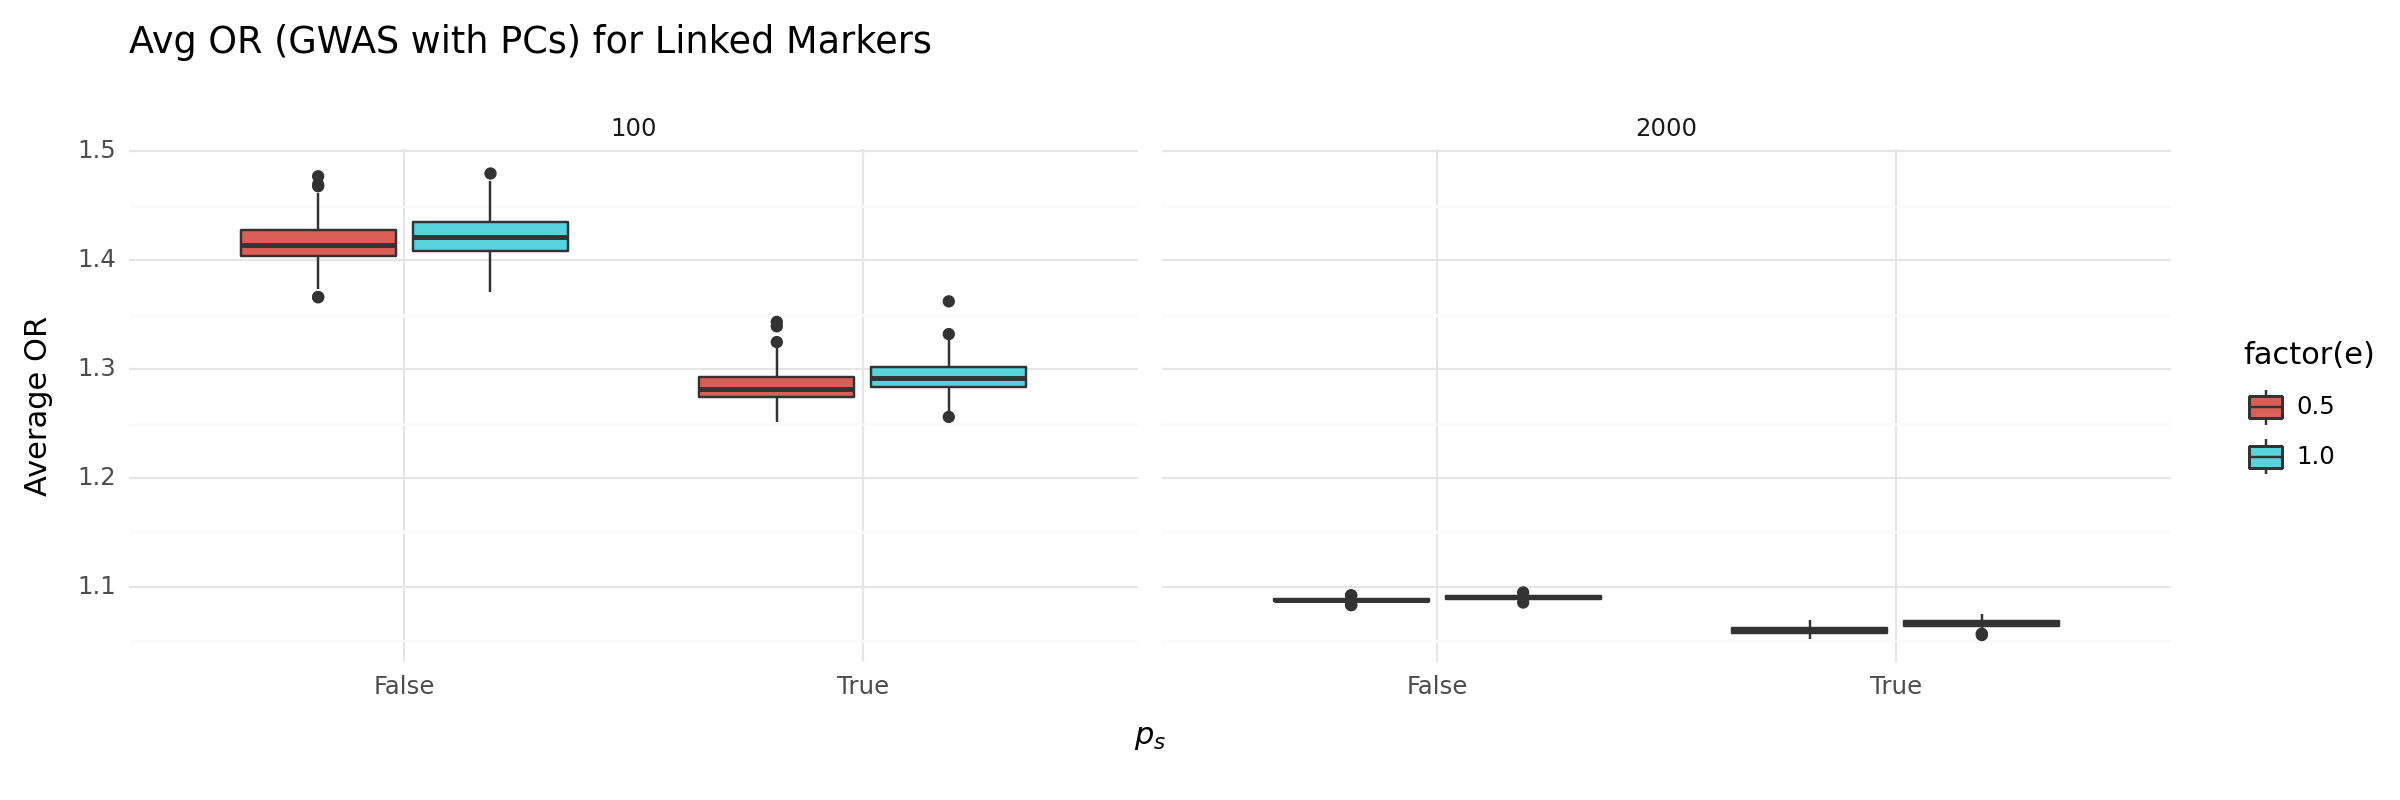

In [97]:
p = (ggplot(results_df, aes(x='ps', y='avg_or_associated_with_pcs',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(12,4))
    + facet_wrap('~num_markers_assoc')
    + labs(title=f'Avg OR (GWAS with PCs) for Linked Markers',y='Average OR',x=r'$p_s$')) 
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 3200 rows containing non-finite values.


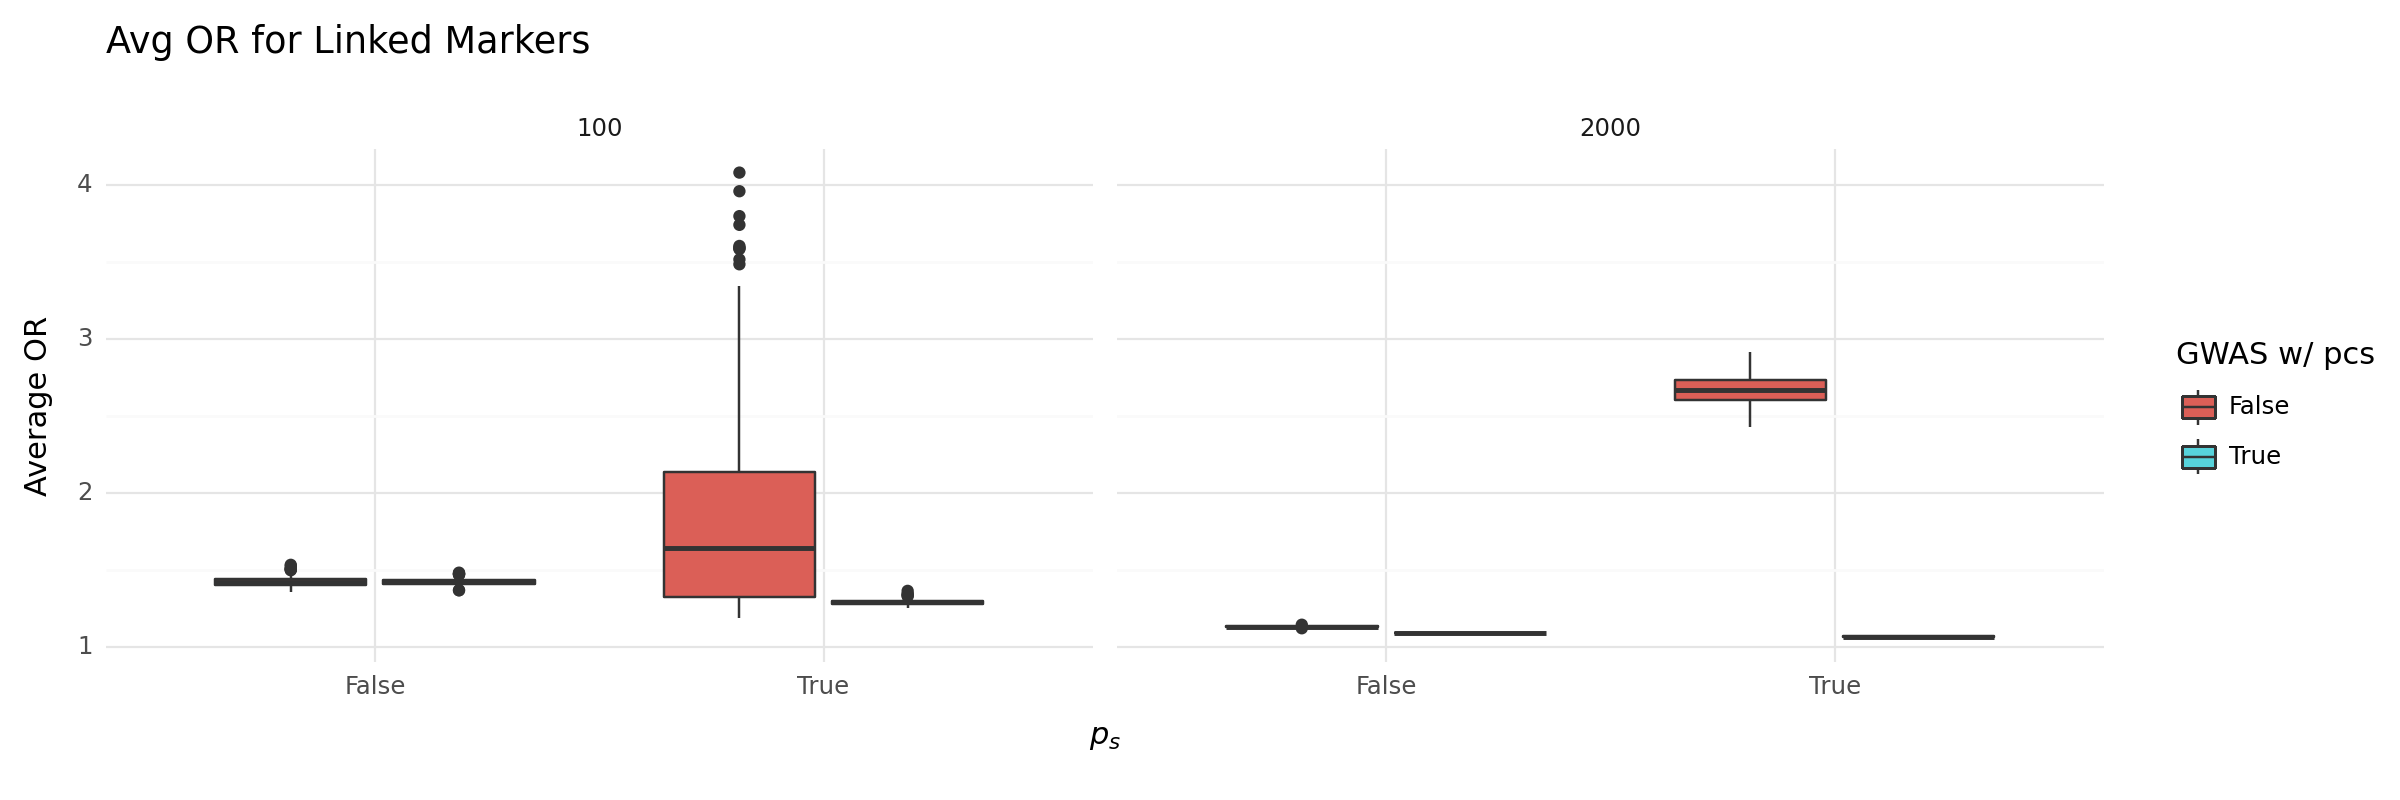

In [98]:
df_long = pd.melt(results_df,
                  id_vars=['ps','num_markers_assoc'],
                  value_vars=['avg_or_associated_with_pcs', 'avg_or_associated_no_pcs'],
                  var_name='GWAS w/ pcs',
                  value_name='Average OR')
df_long['GWAS w/ pcs'] = df_long['GWAS w/ pcs'] == 'avg_or_associated_with_pcs'
df_long
p = (ggplot(df_long, aes(x='ps', y='Average OR',fill='GWAS w/ pcs'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(12,4))
    + facet_wrap('~num_markers_assoc')
    + labs(title=f'Avg OR for Linked Markers',y='Average OR',x=r'$p_s$')) 
print(p)

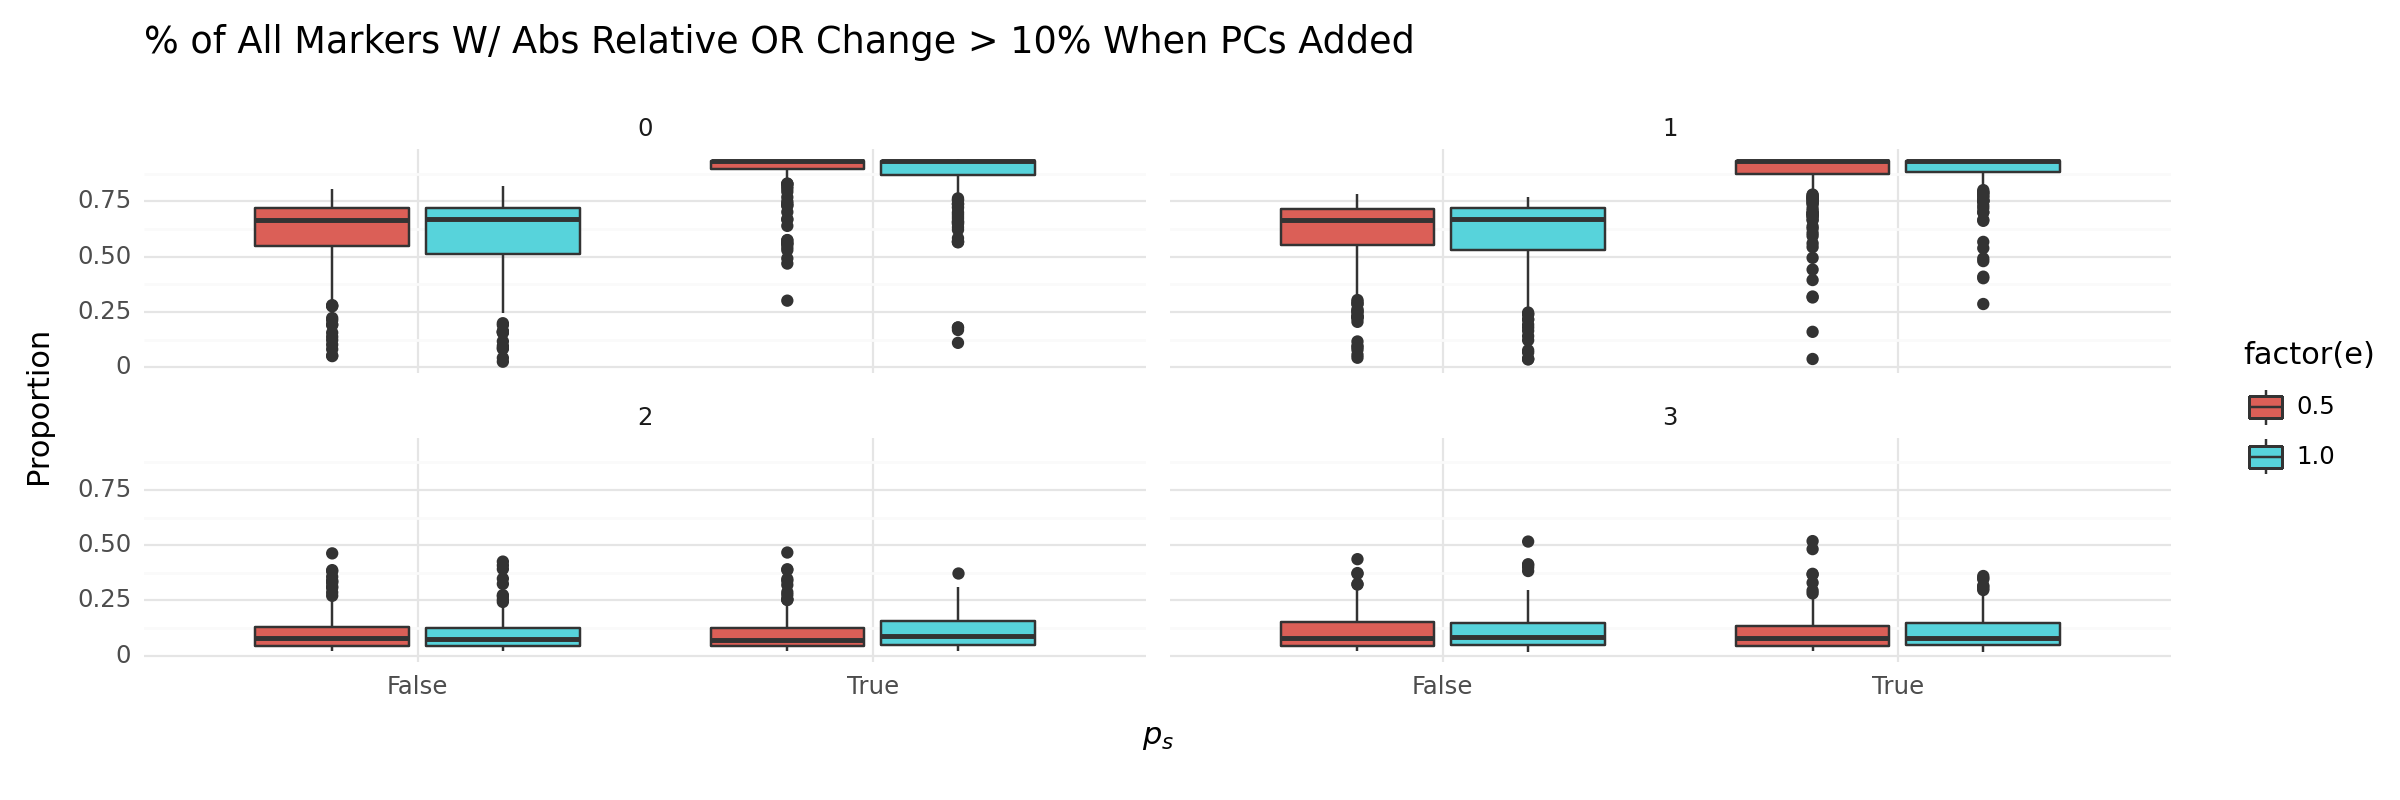

In [102]:
p = (ggplot(results_df, aes(x='ps', y='prop_changed',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(12,4))
    + facet_wrap('~phenotypic_subgroup')
    + labs(title=f'% of All Markers W/ Abs Relative OR Change > 10% When PCs Added',y='Proportion',x=r'$p_s$')) 
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 1600 rows containing non-finite values.


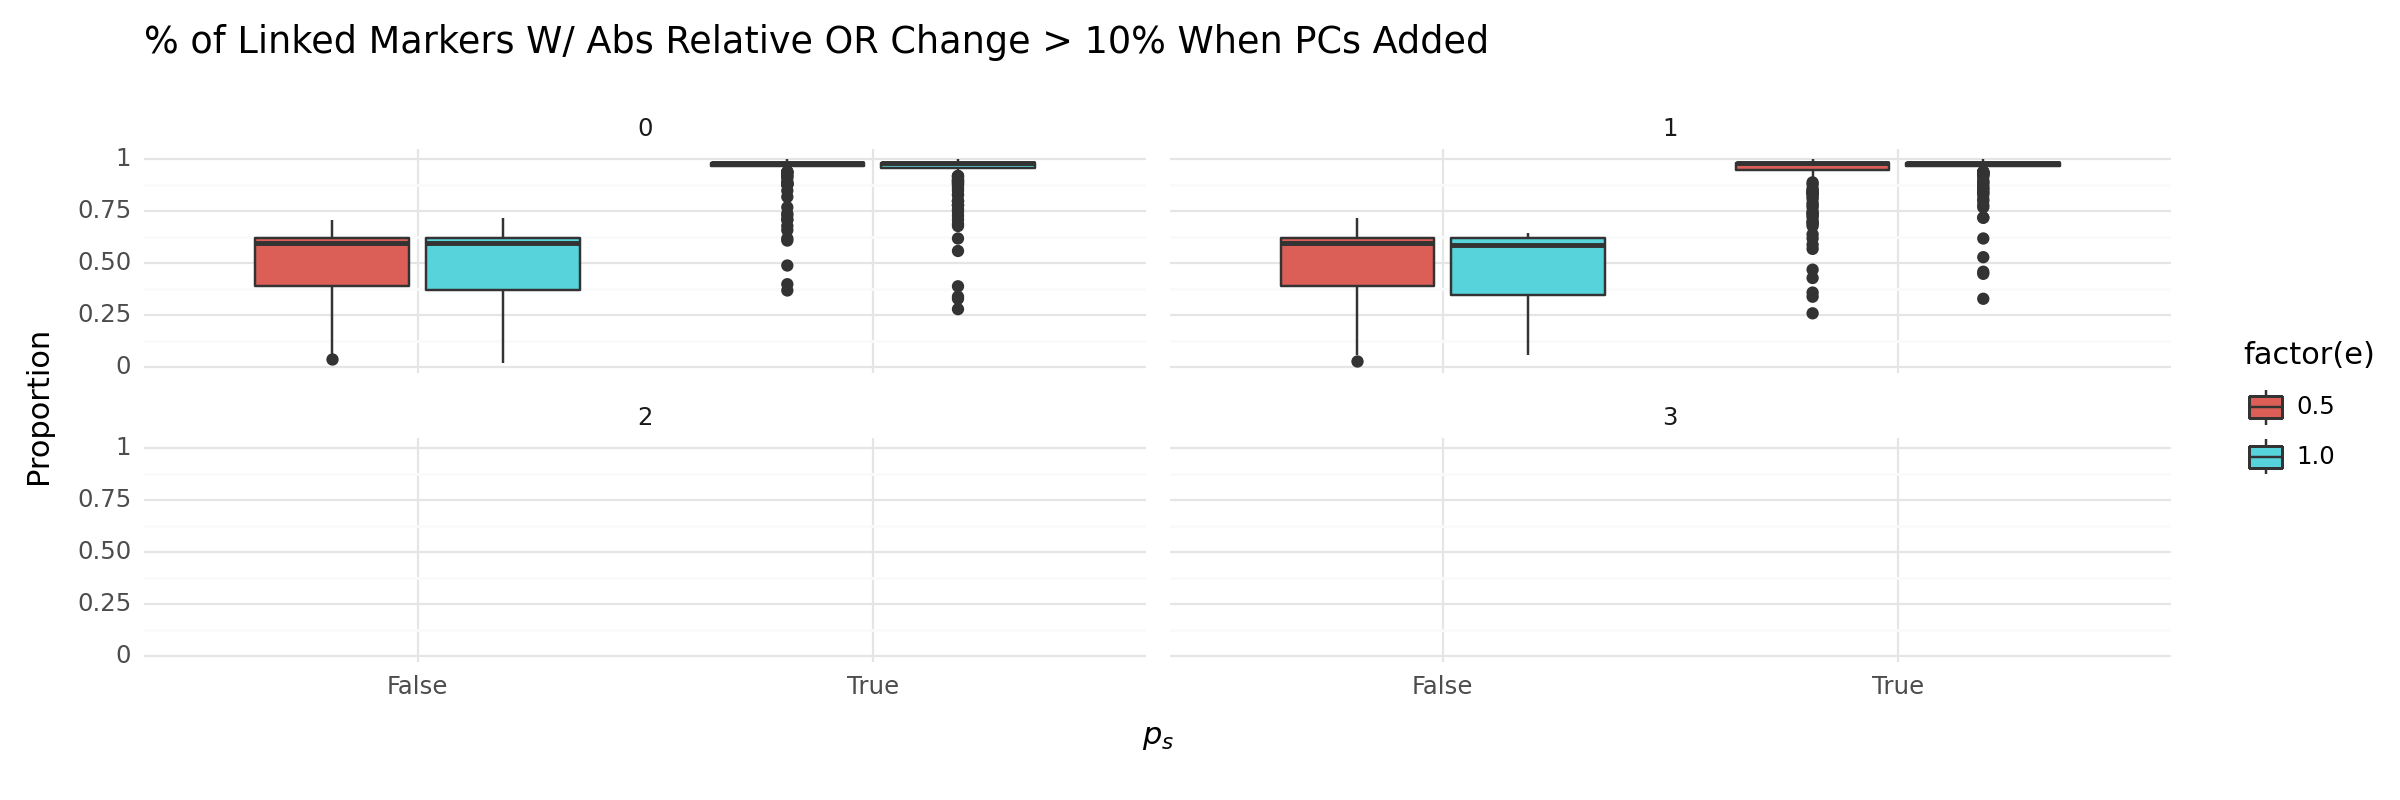

In [104]:
p = (ggplot(results_df, aes(x='ps', y='prop_changed_associated',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(12,4))
    + facet_wrap('~phenotypic_subgroup')
    + labs(title=f'% of Linked Markers W/ Abs Relative OR Change > 10% When PCs Added',y='Proportion',x=r'$p_s$')) 
print(p)

Graphs just for associated markers

In [11]:
# graph pred positive
results_df['pred_pos_with_pcs'] = results_df['fp_with_pcs'] + results_df['tp_with_pcs']
results_df['pred_pos_no_pcs'] = results_df['fp_no_pcs'] + results_df['tp_no_pcs']
df_long = pd.melt(results_df,
                  id_vars=['ps','num_markers_assoc','e','phenotypic_subgroup'],
                  value_vars=['pred_pos_with_pcs', 'pred_pos_no_pcs'],
                  var_name='GWAS w/ pcs',
                  value_name='pred_pos')
df_long['GWAS w/ pcs'] = df_long['GWAS w/ pcs'] == 'pred_pos_with_pcs'

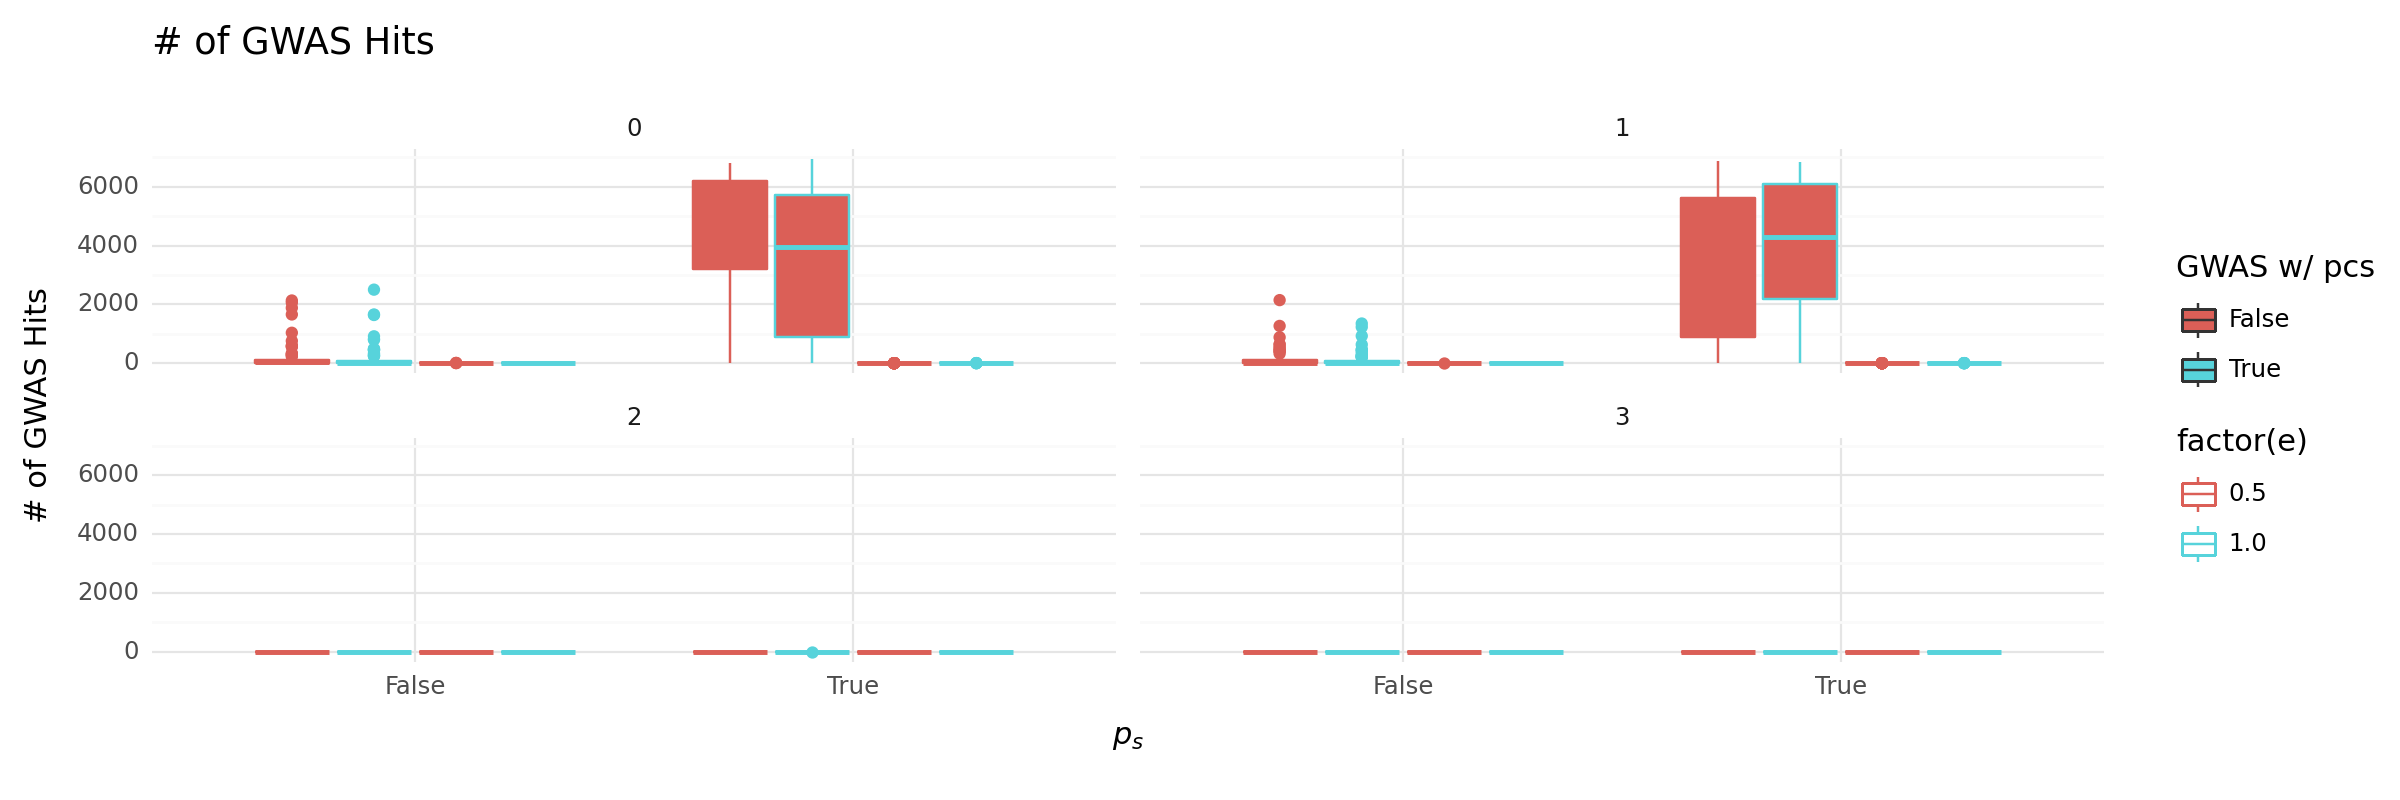

In [15]:
p = (ggplot(df_long[df_long['num_markers_assoc']==100], aes(x='ps', y='pred_pos',fill='GWAS w/ pcs',color='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(12,4))
    + facet_wrap('~phenotypic_subgroup')
    + labs(title=f'# of GWAS Hits',y='# of GWAS Hits',x=r'$p_s$')) 
print(p)

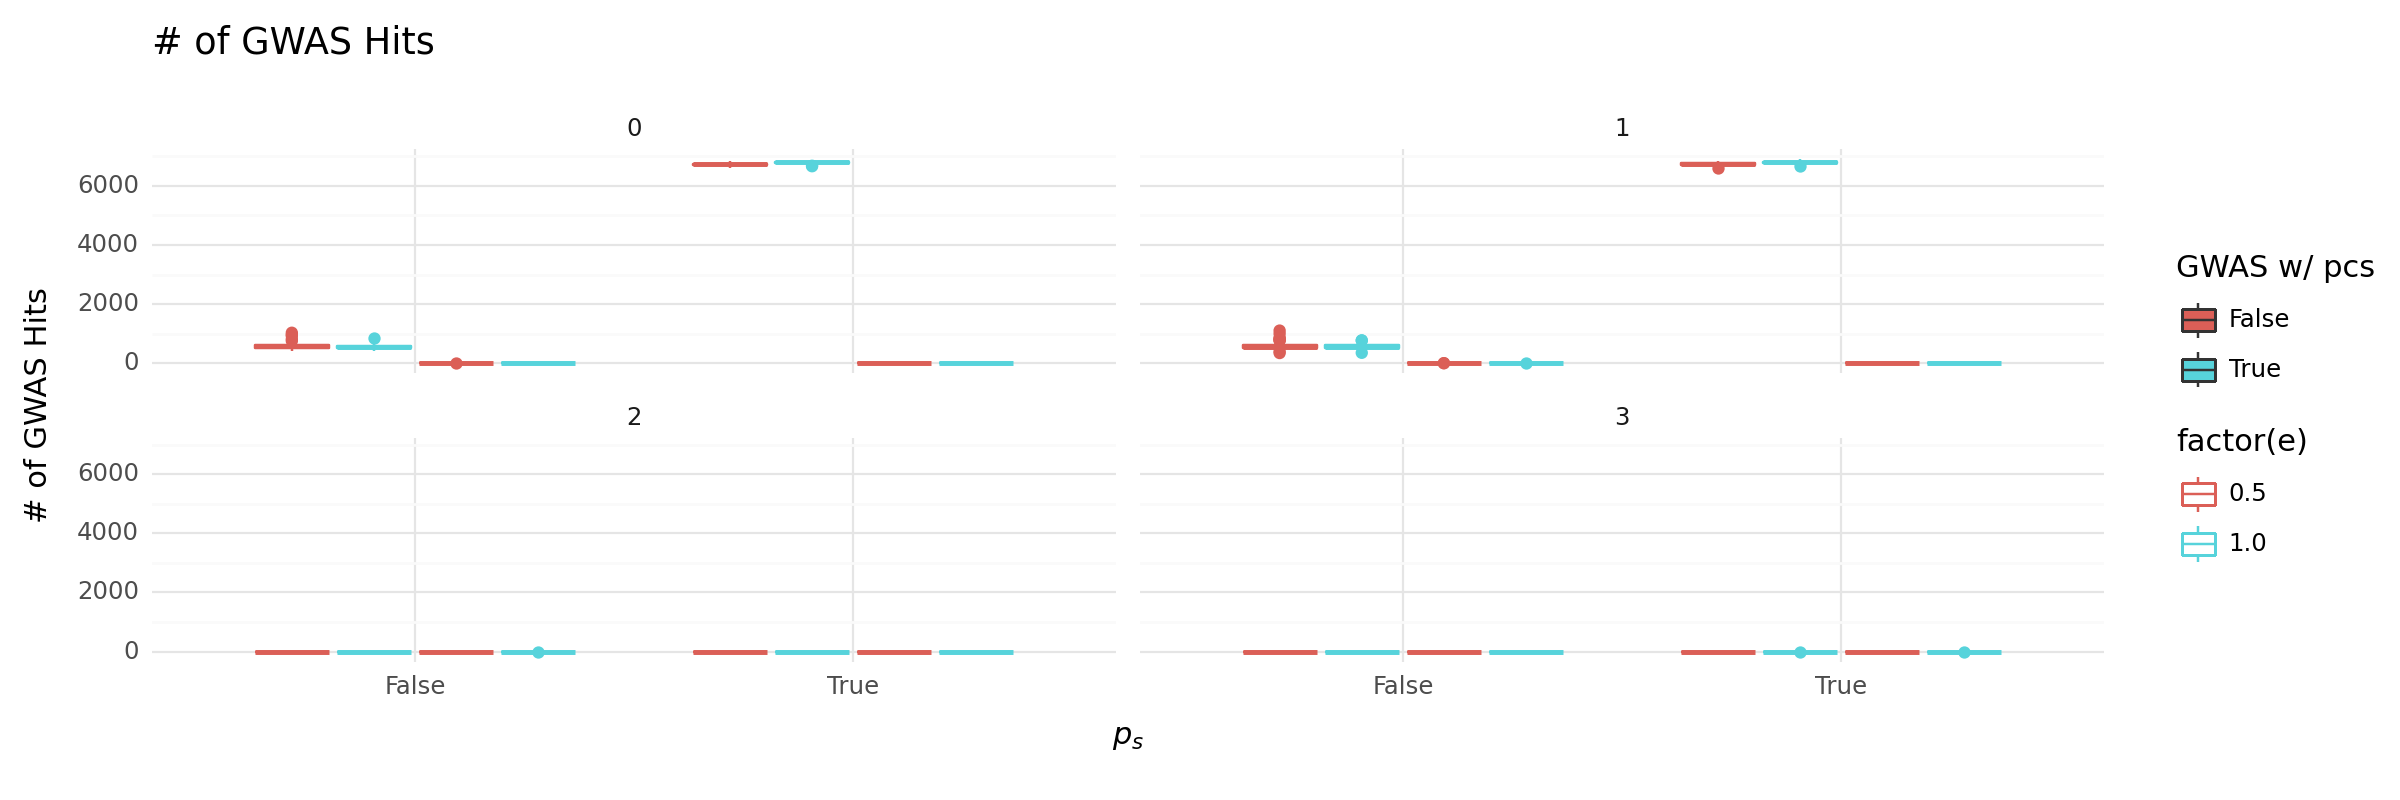

In [16]:
p = (ggplot(df_long[df_long['num_markers_assoc']==2000], aes(x='ps', y='pred_pos',fill='GWAS w/ pcs',color='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(12,4))
    + facet_wrap('~phenotypic_subgroup')
    + labs(title=f'# of GWAS Hits',y='# of GWAS Hits',x=r'$p_s$')) 
print(p)

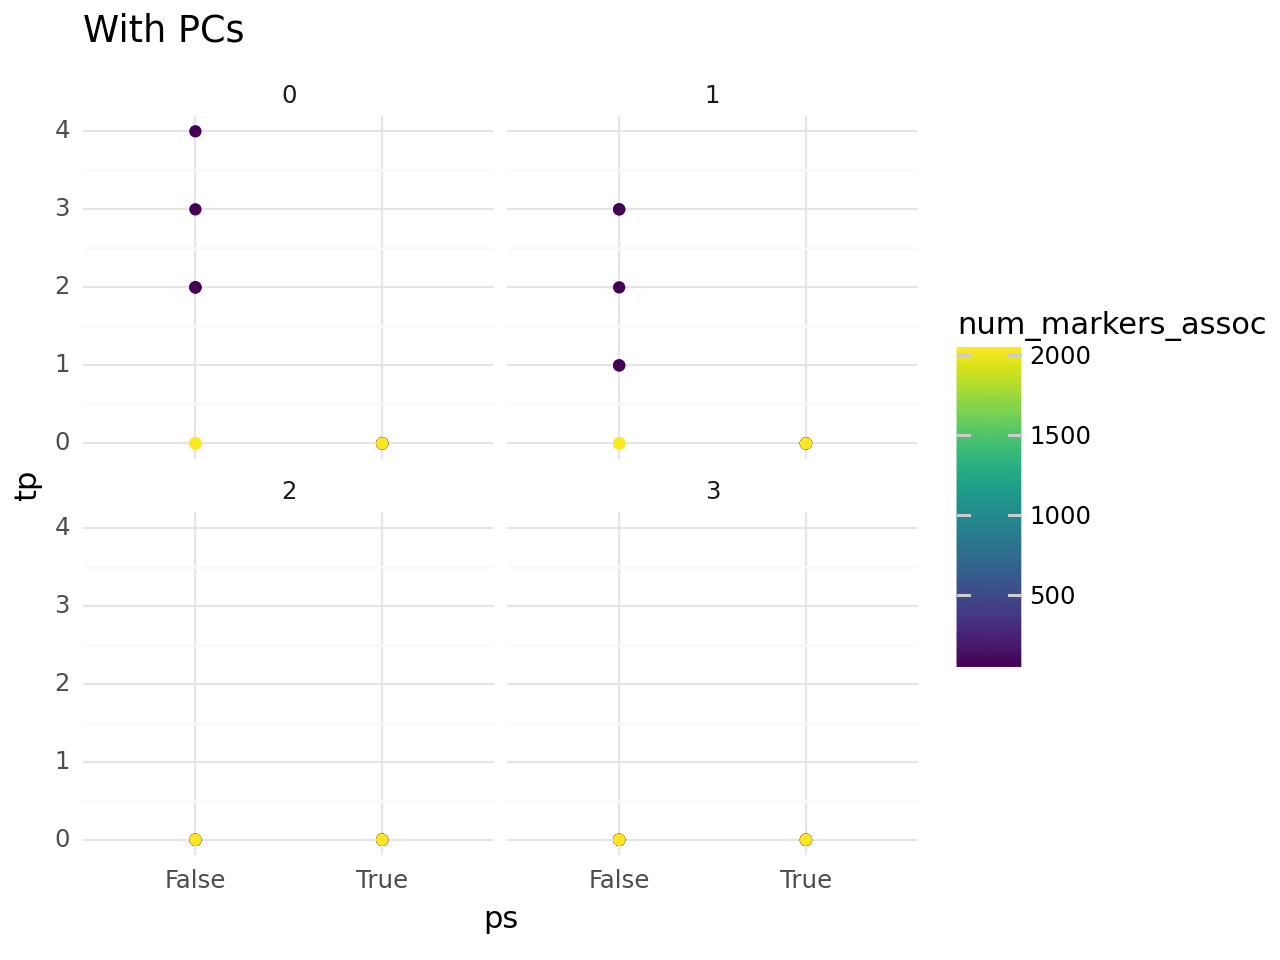

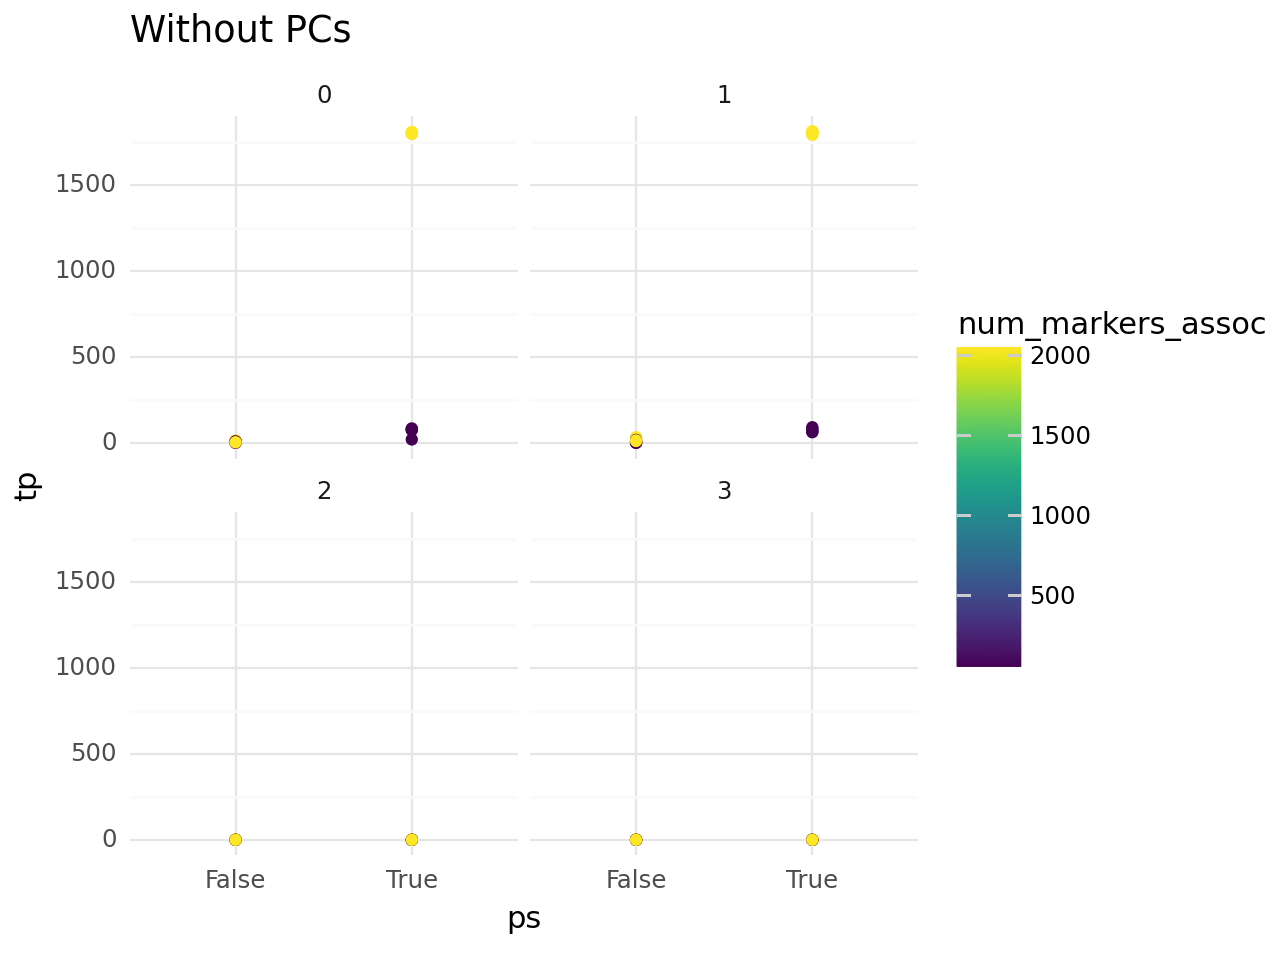

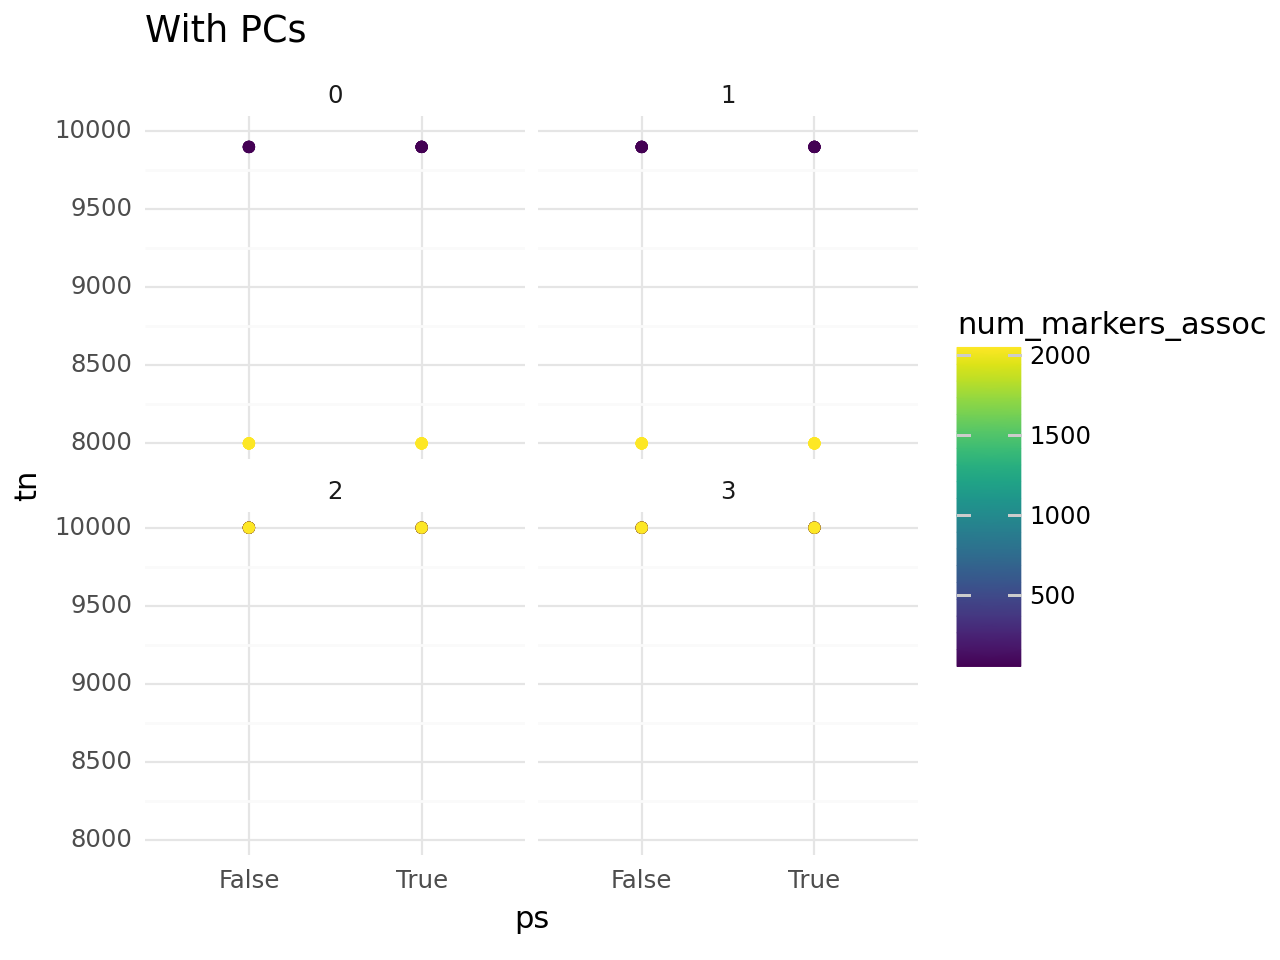

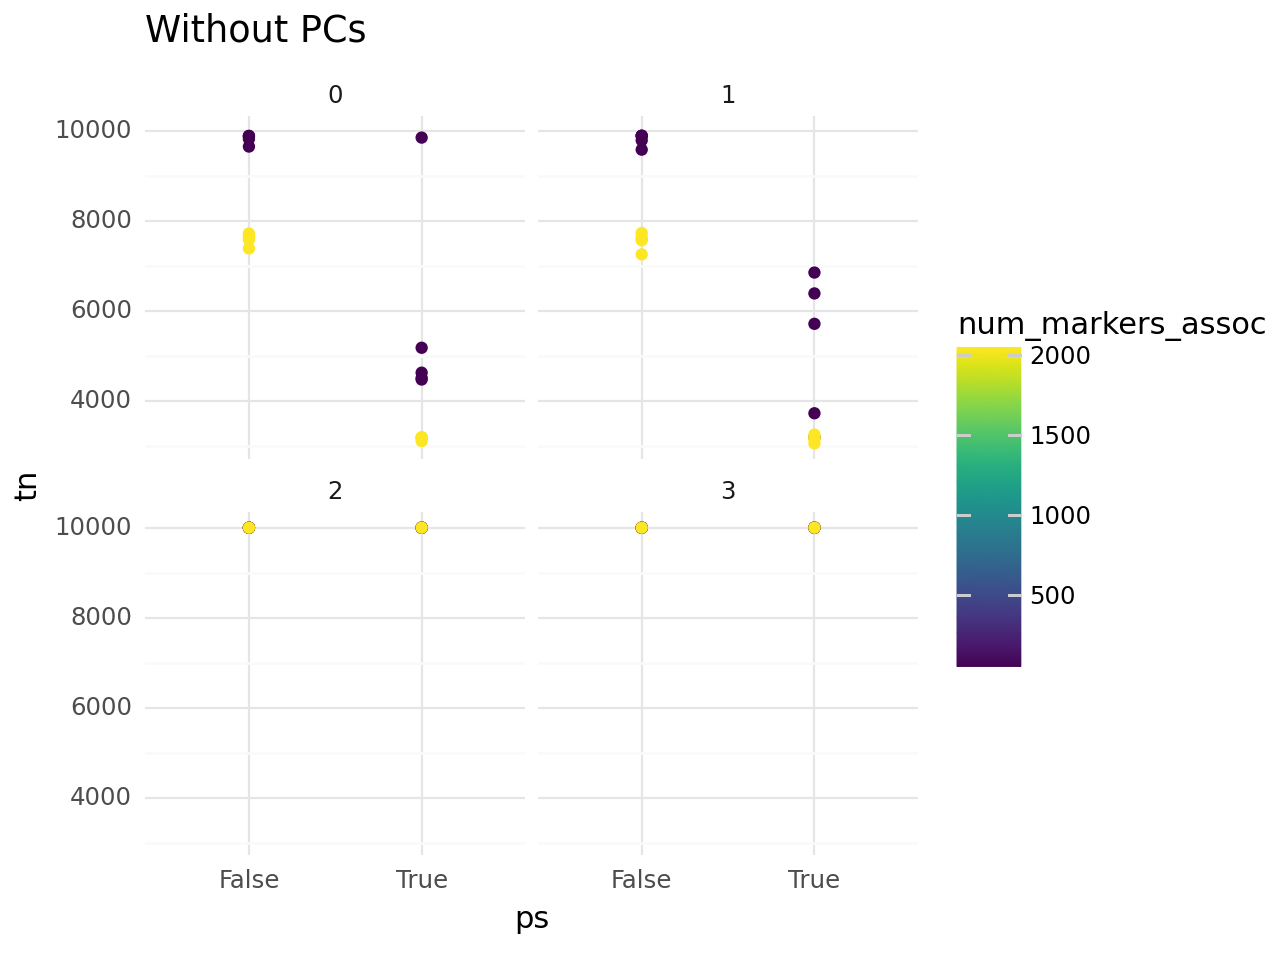

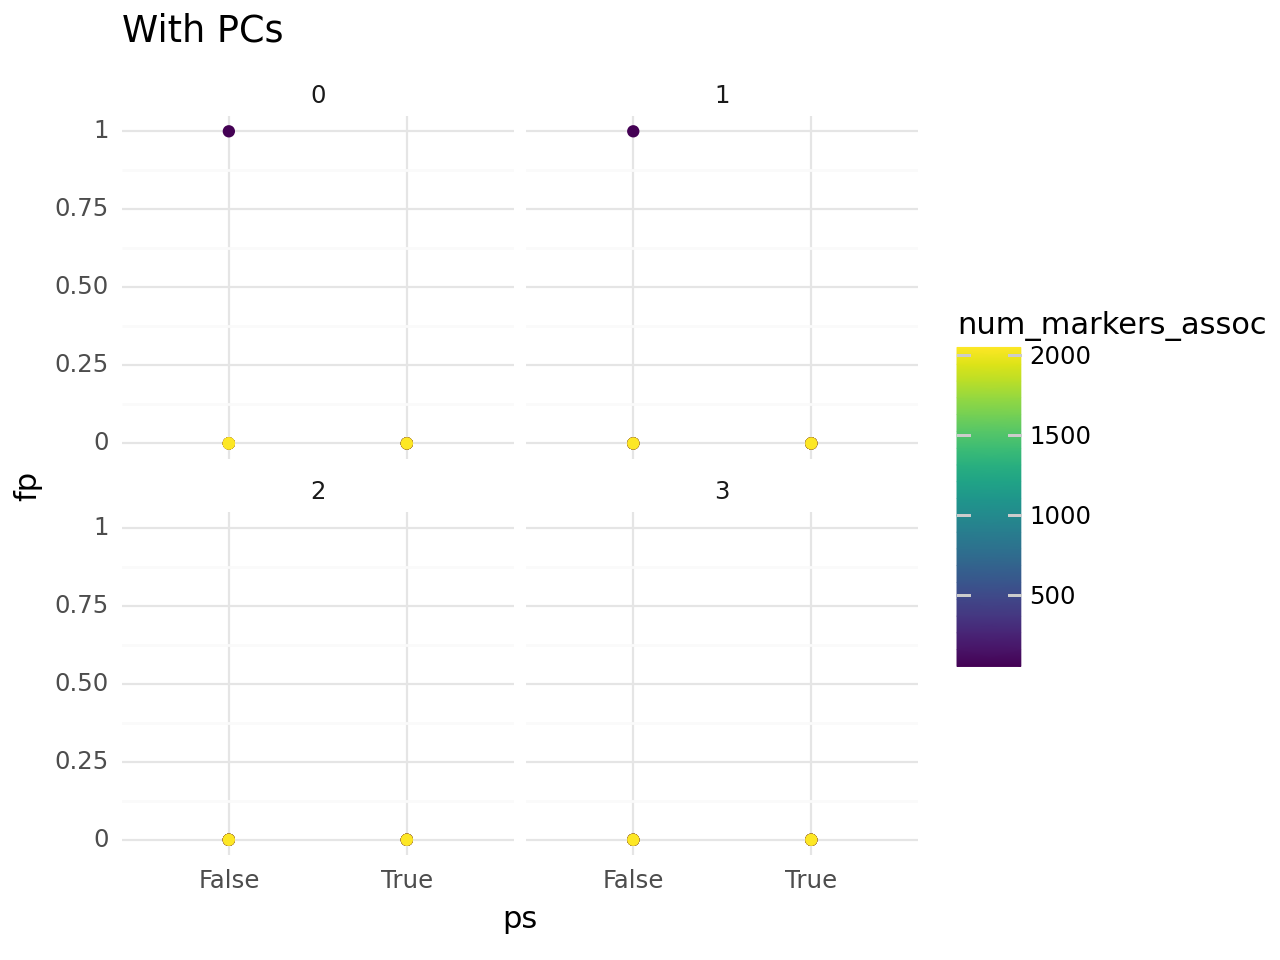

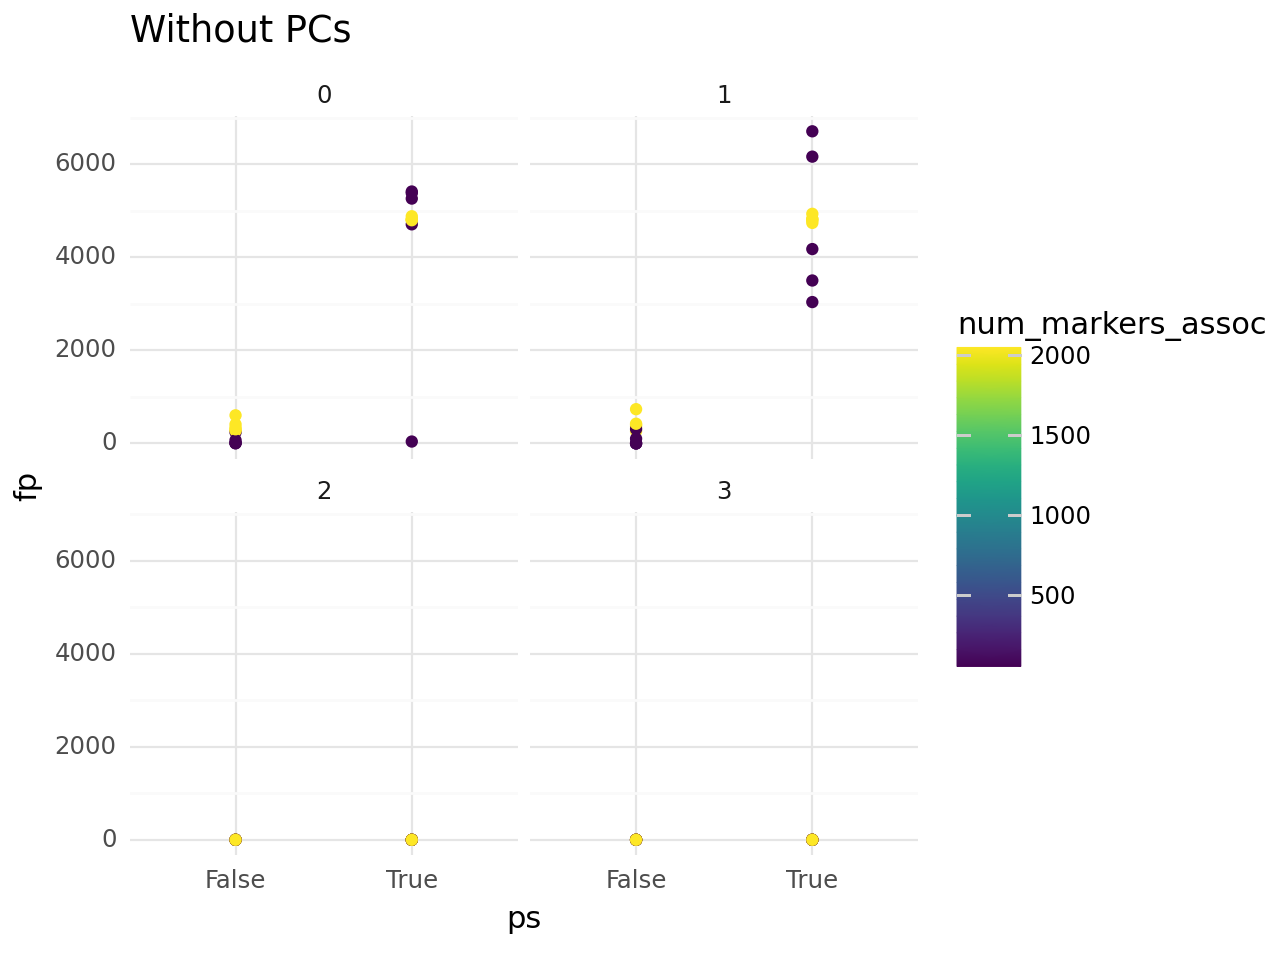

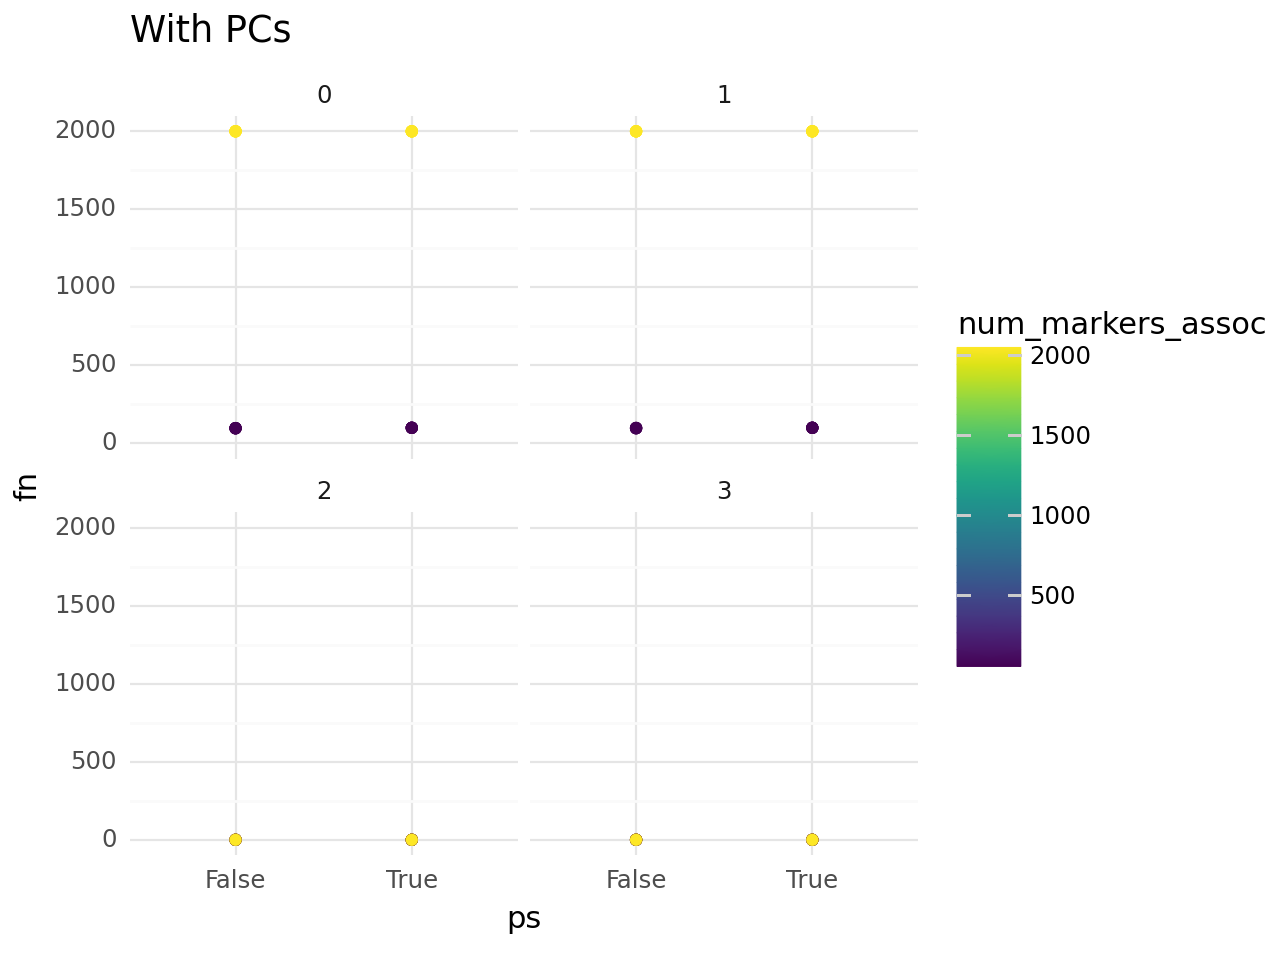

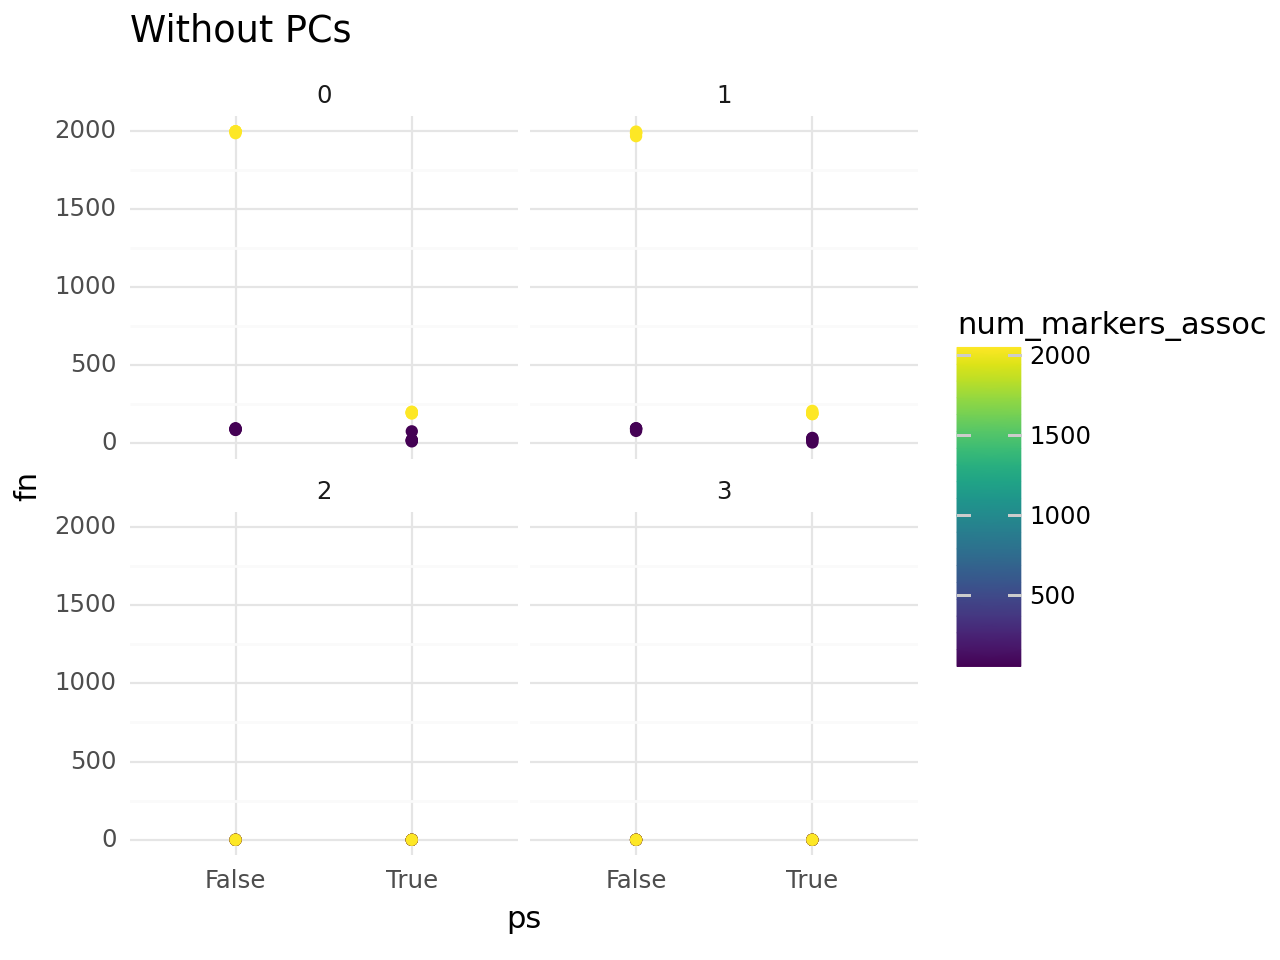

In [14]:
for metric in ['tp','tn','fp','fn']:
     for pcs in [True,False]:
          y_suffix = '_with_cov' if pcs else '_no_cov'
          title = 'With PCs' if pcs else 'Without PCs'
          p = (ggplot(results_df, aes(x='ps', y=f'{metric}{y_suffix}',fill='num_markers_assoc',color='num_markers_assoc'))
               + geom_point()
               + facet_wrap('~phenotypic_subgroup')
               + theme_minimal()
               + labs(title=title,y=metric.replace('_w_pcs',''))) 
          print(p)


In [5]:
for e in [0.5,1.0]:
     for af_variance_grouping in ['admixture','superpopulation']:
          for metric in ['accuracy','precision','recall']:
               title = f'e: {e}, AF variance grouping: {af_variance_grouping}'
               plot_df = results_df[(results_df['af_variance_grouping']==af_variance_grouping)&(results_df['e']==e)].melt(id_vars=["ps","e","phenotypic_subgroup"], value_vars=[f"{metric}_w_pcs", metric],
                         var_name="pcs_included", value_name="value").copy()
               plot_df['pcs_included'] = plot_df['pcs_included'].str.contains("w_pcs")

               p = (ggplot(plot_df, aes(x='ps', y=f'value',fill='pcs_included')) +
                    geom_bar(stat = "identity", position = "dodge") +
                    facet_wrap('~phenotypic_subgroup')
                    + theme_minimal()
                    + labs(title=title,y=metric,fill='PCs Included')) 
               print(p)


NameError: name 'results_df' is not defined

### Algorithm creation

In [6]:
root_dir = '/gpfs/commons/datasets/1000genomes'
import simulations.genomes1000_sim as sim_functions


In [6]:
# empirically, show monotone decrease of loss and stabilization over iterations
# show stability of parameter norms (U^t-U^(t-1))

# JointMF
import algorithms.JointMF as JointMF
import algorithms.JointMF_AAO as JointMF_AAO
import importlib
importlib.reload(JointMF)

writer = None

# read in simulated clinical data
ps = 0.75
e = 0.5
init = 0
num_markers_assoc = 2000
output_suffix = f'ps_{ps}_e_{e}_init_{init}_markersassoc_{num_markers_assoc}'
C = np.load(f'{output_dir}/C_{output_suffix}.npy')
with open(f"{output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
    simulation_metadata = pickle.load(f)

# read in admixture fractions, sex and G
igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{output_dir}/G')
igsr_samples['Sex'] = igsr_samples['Sex'].map({'female': 0, 'male': 1})

admixture = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
fam_df = pd.read_csv(f'{output_dir}/G.fam',sep='\s+',header=None)
fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
admixture['IID'] = fam_df['IID'].values
Z_df = admixture.merge(igsr_samples[['IID','Sex']], on='IID',how='inner')
Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy()

G = np.loadtxt(f'{output_dir}/G.raw',  usecols=range(6, 193634+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)


ML Flow practice

In [10]:
import mlflow
from mlflow import MlflowClient
from mlflow.models import infer_signature

import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


host="127.0.0.1"
port="8080"
# mlflow.set_tracking_uri(uri=f"http://{host}:{port}")
# mlflow.set_experiment("MLflow Quickstart")

client = MlflowClient(tracking_uri=f"http://{host}:{port}")
exp_name = "MLflow Quickstart2"
exp_id = client.create_experiment(
    exp_name,
    artifact_location="file:/abs/path/per_experiment_artifacts"  
)
mlflow.set_experiment(exp_name)

# Load the Iris dataset
X, y = datasets.load_iris(return_X_y=True)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters
params = {
    "solver": "lbfgs",
    "max_iter": 1000,
    "multi_class": "auto",
    "random_state": 8888,
}

# Train the model
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

# Predict on the test set
y_pred = lr.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)

with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("accuracy", accuracy)

    # Infer the model signature
    signature = infer_signature(X_train, lr.predict(X_train))

    # # Log the model, which inherits the parameters and metric
    # model_info = mlflow.sklearn.log_model(
    #     sk_model=lr,
    #     name="iris_model",
    #     signature=signature,
    #     input_example=X_train,
    #     registered_model_name="tracking-quickstart",
    # )

    # # Set a tag that we can use to remind ourselves what this model was for
    # mlflow.set_logged_model_tags(
    #     model_info.model_id, {"Training Info": "Basic LR model for iris data"}
    # )

🏃 View run sincere-shoat-49 at: http://127.0.0.1:8080/#/experiments/953306339708230954/runs/0be7ce6cbfe642e7ae199587d2a4b1b4
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/953306339708230954


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


Force alternating optimization

In [4]:
def mats2vec(mats):
    """ Converts matrices back to vector form."""
    return np.concatenate([mat.flatten(order='F') for mat in mats])

def vec2mats(v, shapes): 
    """ Converts a vector into matrices based on given shapes.
    shapes is list of tuples defining shapes of each matrix to be formed
    """
    place_sum = 0
    mats = []
    for dim in shapes:
        size = dim[0]*dim[1]
        mats.append(v[place_sum:place_sum+size].reshape(dim[0], dim[1], order='F'))
        place_sum += size
    return mats

In [5]:
from scipy.special import gammaln

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [24]:
def total_loss(G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # define nec. elements
    G_hat = sigmoid(W@H_G.T + Z@U_G.T)
    # clipping for log purposes
    G_hat = np.clip(G_hat, 1e-7, 1 - 1e-7)
    C_hat = W@H_C.T + Z@U_C.T
    # clipping for log purposes
    C_hat = np.clip(C_hat, 1e-7, 1 - 1e-7)

    E_g = np.ones(G.shape)

    # define loss
    bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
    kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat + gammaln(C + 1)) # log(C!) can help stabilize
    regularization = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    if kl_div_loss < 0:
        assert True == False, "KL divergence loss negative"
    if bce_loss < 0:
        assert True == False, "BCE loss negative"
    f = bce_loss + kl_div_loss + regularization 
    return f

# Per-block factories (compute precomputes once per inner solve)

def make_fg_W(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of W
    U1 = Z@U_G.T
    U2 = Z@U_C.T
    C_const = np.sum(gammaln(C + 1))
    E_g = np.ones(G.shape)
    E_c = np.ones(C.shape)
    reg = lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        W = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)
        # clipping for log purposes
        C_hat = np.clip(W@H_C.T + U2, 1e-7, 1 - 1e-7)
        bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
        kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat) + C_const # log(C!) can help stabilize
        f = bce_loss + kl_div_loss + lambda_W/2* np.trace(W.T @ W) + reg 
        return f
    def jac(x):
        W = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)
        # clipping for log purposes
        C_hat = np.clip(W@H_C.T + U2, 1e-7, 1 - 1e-7)

        G_tilde = np.divide(G,G_hat)
        G_bar = np.divide(E_g-G,E_g-G_hat)
        C_tilde = np.divide(C,C_hat)

        GW = (np.multiply(np.multiply(-G_tilde + G_bar,G_hat),E_g - G_hat)@H_G 
                + (E_c - C_tilde)@H_C + lambda_W*W)
        return GW.flatten(order='F')
    return fun, jac

def make_fg_HG(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of H_G
    U1 = Z@U_G.T
    C_hat = np.clip(W@H_C.T + Z@U_C.T, 1e-7, 1 - 1e-7)
    kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat + gammaln(C + 1)) # log(C!) can help stabilize
    E_g = np.ones(G.shape)
    reg = lambda_W/2* np.trace(W.T @ W) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        H_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)
        bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
        f = bce_loss + kl_div_loss + reg +  lambda_H_G/2* np.trace(H_G.T @ H_G)
        return f
    def jac(x):
        H_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)

        G_tilde = np.divide(G,G_hat)
        G_bar = np.divide(E_g-G,E_g-G_hat)

        GH_G = (W.T@np.multiply(np.multiply(-G_tilde + G_bar,G_hat),E_g - G_hat)).T + lambda_H_G*H_G
        return GH_G.flatten(order='F')
    return fun, jac

def make_fg_HC(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of H_C
    U1 = Z@U_C.T
    E_c = np.ones(C.shape)
    C_const = np.sum(gammaln(C + 1))
    G_hat = np.clip(sigmoid(W@H_G.T + Z@U_G.T), 1e-7, 1 - 1e-7)
    E_g = np.ones(G.shape)
    bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
    reg = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G)
    def fun(x):
        H_C = x.reshape(shape, order='F')
        C_hat = np.clip(W@H_C.T + U1, 1e-7, 1 - 1e-7)
        kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat) + C_const # log(C!) can help stabilize
        f = bce_loss + kl_div_loss + reg +  lambda_H_C/2* np.trace(H_C.T @ H_C)
        return f
    def jac(x):
        H_C = x.reshape(shape, order='F')
        C_hat = np.clip(W@H_C.T + U1, 1e-7, 1 - 1e-7)

        C_tilde = np.divide(C,C_hat)

        GH_C = (W.T@(E_c - C_tilde)).T + lambda_H_C*H_C
        return GH_C.flatten(order='F')
    return fun, jac

def make_fg_UG(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of U_G
    U1 = W@H_G.T
    C_hat = np.clip(W@H_C.T + Z@U_C.T, 1e-7, 1 - 1e-7)
    kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat + gammaln(C + 1)) # log(C!) can help stabilize
    E_g = np.ones(G.shape)
    regularization = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        U_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(U1 + Z@U_G.T), 1e-7, 1 - 1e-7)
        bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
        f = bce_loss + kl_div_loss + regularization
        return f
    def jac(x):
        U_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(U1 + Z@U_G.T), 1e-7, 1 - 1e-7)

        G_tilde = np.divide(G,G_hat)
        G_bar = np.divide(E_g-G,E_g-G_hat)

        GU_G = (Z.T@(np.multiply(np.multiply(-G_tilde + G_bar,G_hat),E_g - G_hat))).T
        return GU_G.flatten(order='F')
    return fun, jac

def make_fg_UC(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of U_C
    U1 = W@H_C.T
    E_c = np.ones(C.shape)
    C_const = np.sum(gammaln(C + 1))
    G_hat = np.clip(sigmoid(W@H_G.T + Z@U_G.T), 1e-7, 1 - 1e-7)
    E_g = np.ones(G.shape)
    bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
    regularization = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        U_C = x.reshape(shape, order='F')
        C_hat = np.clip(U1 + Z@U_C.T, 1e-7, 1 - 1e-7)
        kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat) + C_const
        f = bce_loss + kl_div_loss + regularization
        return f
    def jac(x):
        U_C = x.reshape(shape, order='F')
        C_hat = np.clip(U1 + Z@U_C.T, 1e-7, 1 - 1e-7)

        C_tilde = np.divide(C,C_hat)

        GU_C = (Z.T@(E_c - C_tilde)).T
        return GU_C.flatten(order='F')
    return fun, jac

In [30]:
import numpy as np
from scipy.optimize import minimize

def alternating_opt(
    G,C,Z,              # true matrices
    W, H_G, H_C, U_G, U_C,  # initializations
    lambda_W, lambda_H_G, lambda_H_C,                   # regularization parameters
    method,                 # method and options for scipy minimize
    options,
    max_outer=30,
    tol=1e-4,
    nonneg=True             # set per-block L-BFGS-B bounds to [0, +inf)
):
    def one_block_update(name, X, method, options):
        x0 = X.flatten(order='F') 
        bnds = [(0, None)] * x0.size if nonneg else None

        if name == "W":
            fun, jac = make_fg_W(W.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "H_G":
            fun, jac = make_fg_HG(H_G.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "H_C":
            fun, jac = make_fg_HC(H_C.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "U_G":
            fun, jac = make_fg_UG(U_G.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "U_C":
            fun, jac = make_fg_UC(U_C.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        else:
            raise ValueError(f"Unknown block {name}")

        res = minimize(fun, x0, method=method, jac=jac, bounds=bnds, options=options)
        return res.x.reshape(X.shape, order='F')

    # initial objective
    f_prev = total_loss(G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)

    for _ in range(max_outer):
        W   = one_block_update("W",   W, method, options)
        H_G = one_block_update("H_G", H_G, method, options)
        H_C = one_block_update("H_C", H_C, method, options)
        U_G = one_block_update("U_G", U_G, method, options)
        U_C = one_block_update("U_C", U_C, method, options)

        f_cur = total_loss(G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        print(f_cur)
        if (f_prev - f_cur) / max(1.0, abs(f_prev)) < tol:
            break
        f_prev = f_cur

    return W, H_G, H_C, U_G, U_C


In [12]:
rank = 4
col = 1000
lambda_W=1
lambda_H_G=1
lambda_H_C=1
W = np.random.random((G[:,:col].shape[0], rank)) # TODO: stop taking first 100 rows
H_G = np.random.random((G[:,:col].shape[1], rank))
H_C = np.random.random((C.shape[1], rank))
U_G = np.random.random((G[:,:col].shape[1], Z.shape[1]))
U_C = np.random.random((C.shape[1], Z.shape[1]))
W, H_G, H_C, U_G, U_C, loss_history, success, message = JointMF_AAO.jmf(G[:,:col], C, Z, rank=4, lambda_W=1, lambda_H_G=1, lambda_H_C=1, 
                                                             method='L-BFGS-B', writer=writer, options={'maxcor':5, 'maxiter':1000, 'gtol':1e-5, 'maxls':10, 'ftol':1e-9},
                                                             W=W, H_G=H_G, H_C=H_C, U_G=U_G, U_C=U_C) # TODO: only taking first 100 rows

In [ ]:
W = np.random.random((G[:,:col].shape[0], rank)) # TODO: stop taking first 100 rows
H_G = np.random.random((G[:,:col].shape[1], rank))
H_C = np.random.random((C.shape[1], rank))
U_G = np.random.random((G[:,:col].shape[1], Z.shape[1]))
U_C = np.random.random((C.shape[1], Z.shape[1]))
W1, H_G1, H_C1, U_G1, U_C1 = JointMF.alternating_opt(G[:,:col],C,Z,W, H_G, H_C, U_G, U_C,lambda_W, lambda_H_G, lambda_H_C, 
    method='L-BFGS-B',options={'maxcor':5, 'maxiter':500, 'gtol':1e-5, 'maxls':10, 'ftol':1e-5},tol=1e-4)

In [43]:
assert all(np.isclose(W,W1).ravel())
assert all(np.isclose(H_G,H_G1).ravel())
assert all(np.isclose(H_C,H_C1,atol=1e-04).ravel(),)
assert all(np.isclose(U_G,U_G1).ravel())
assert all(np.isclose(U_C,U_C1).ravel())

In [53]:
plink_results = pd.read_csv(f'/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/GWAS_RESULTS/PhenotypicSubgroup0_ps_0.75_e_0.5_init_11_markersassoc_100_Geno_Cov_True.Phenotype.glm.logistic.hybrid',sep='\t')


In [56]:
assert plink_results[(plink_results['TEST']=='ADD')].shape[0] == 193634